In [4]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [16]:
df=pd.read_csv('data/StudentsPerformance.csv')

In [17]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [18]:
df.shape

(1000, 8)

In [19]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [22]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

In [23]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [24]:
print("categories in 'gender' variable: ", end=" ")
print(df['gender'].unique())
print("categories in 'race/ethnicity' variable: ", end=" ")
print(df['race/ethnicity'].unique())
print("categories in 'parental level of education' variable: ", end=" ")
print(df['parental level of education'].unique())           
print("categories in 'lunch' variable: ", end=" ")
print(df['lunch'].unique())
print("categories in 'test preparation course' variable: ", end=" ")
print(df['test preparation course'].unique())


categories in 'gender' variable:  ['female' 'male']
categories in 'race/ethnicity' variable:  ['group B' 'group C' 'group A' 'group D' 'group E']
categories in 'parental level of education' variable:  ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
categories in 'lunch' variable:  ['standard' 'free/reduced']
categories in 'test preparation course' variable:  ['none' 'completed']


In [25]:
numeric_fetures=[feature for feature in df.columns if df[feature].dtype!='O']
categorical_fetures=[feature for feature in df.columns if df[feature].dtype=='O']
print("Numeric features: ", numeric_fetures)
print("Categorical features: ", categorical_fetures)

Numeric features:  ['math score', 'reading score', 'writing score']
Categorical features:  ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


In [26]:
df['total_score']=df['math score']+df['reading score']+df['writing score']
df['average_score']=df['total_score']/3
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [27]:
reading_full=df[df['reading score']==100]['average_score'].count()
writing_full=df[df['writing score']==100]['average_score'].count()
math_full=df[df['math score']==100]['average_score'].count()
print("Number of students who scored full marks in reading: ", reading_full)
print("Number of students who scored full marks in writing: ", writing_full)
print("Number of students who scored full marks in math: ", math_full)


Number of students who scored full marks in reading:  17
Number of students who scored full marks in writing:  14
Number of students who scored full marks in math:  7


In [29]:
reading_less_20=df[df['reading score']<20]['average_score'].count()
writing_less_20=df[df['writing score']<20]['average_score'].count()
math_less_20=df[df['math score']<20]['average_score'].count()
print("Number of students who scored less than 20 marks in reading: ", reading_less_20)
print("Number of students who scored less than 20 marks in writing: ", writing_less_20)
print("Number of students who scored less than 20 marks in math: ", math_less_20)

Number of students who scored less than 20 marks in reading:  1
Number of students who scored less than 20 marks in writing:  3
Number of students who scored less than 20 marks in math:  4


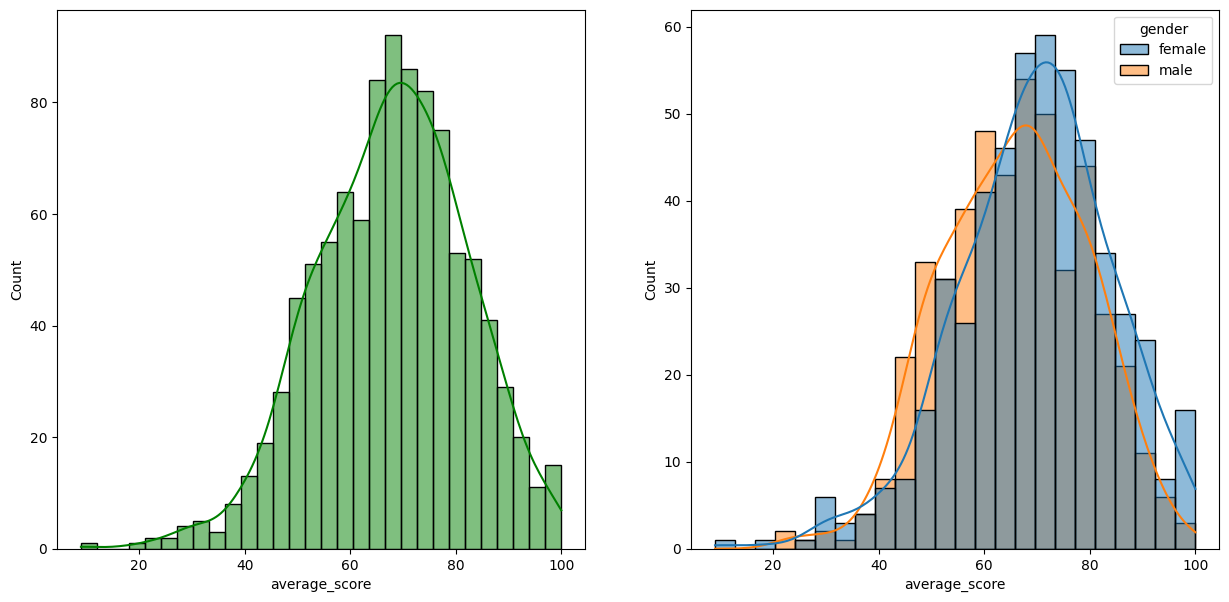

In [31]:
fig,axs=plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df,x='average_score',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='average_score',kde=True,hue='gender')
plt.show()

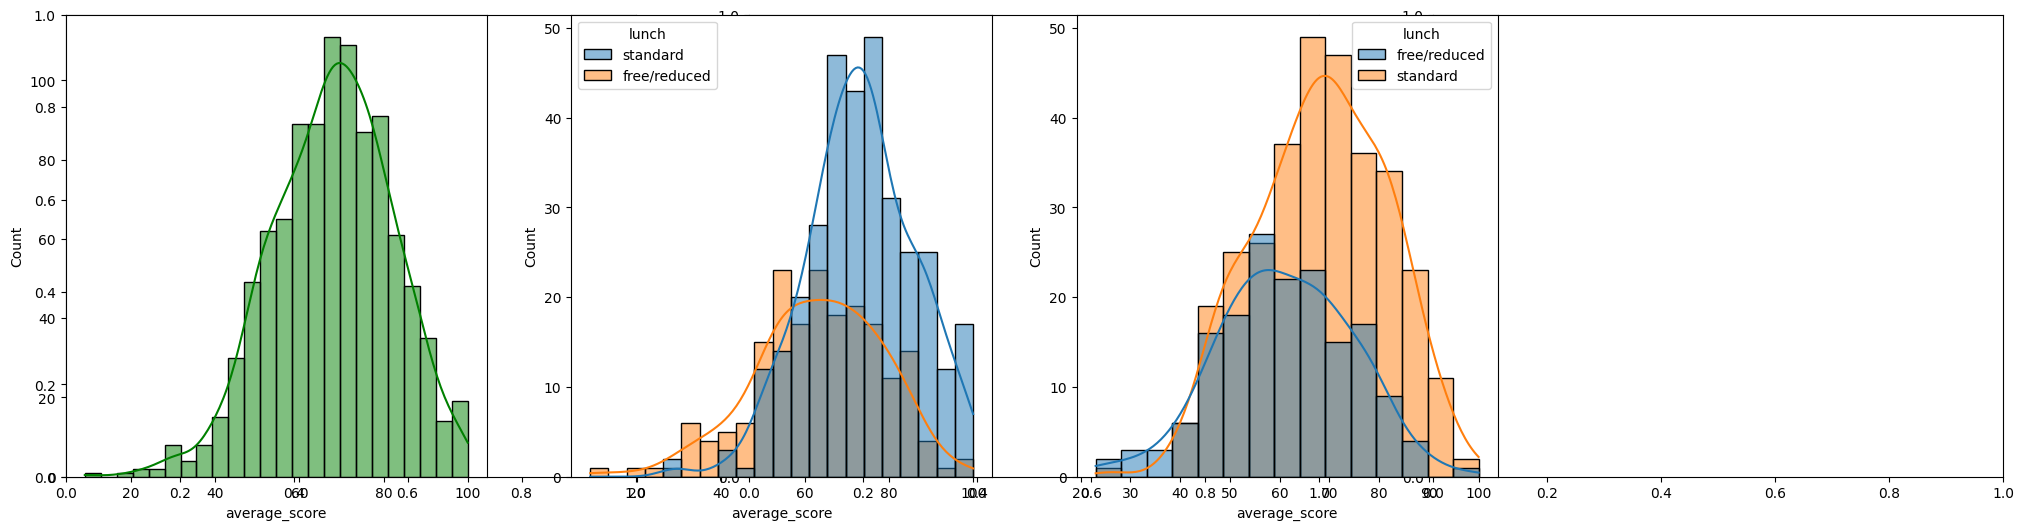

In [32]:
fig,axs=plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.histplot(data=df,x='average_score',kde=True,color='g')
plt.subplot(142)
sns.histplot(data=df[df.gender=='female'],x='average_score',kde=True,hue='lunch')
plt.subplot(143)
sns.histplot(data=df[df.gender=='male'],x='average_score',kde=True,hue='lunch')
plt.show()

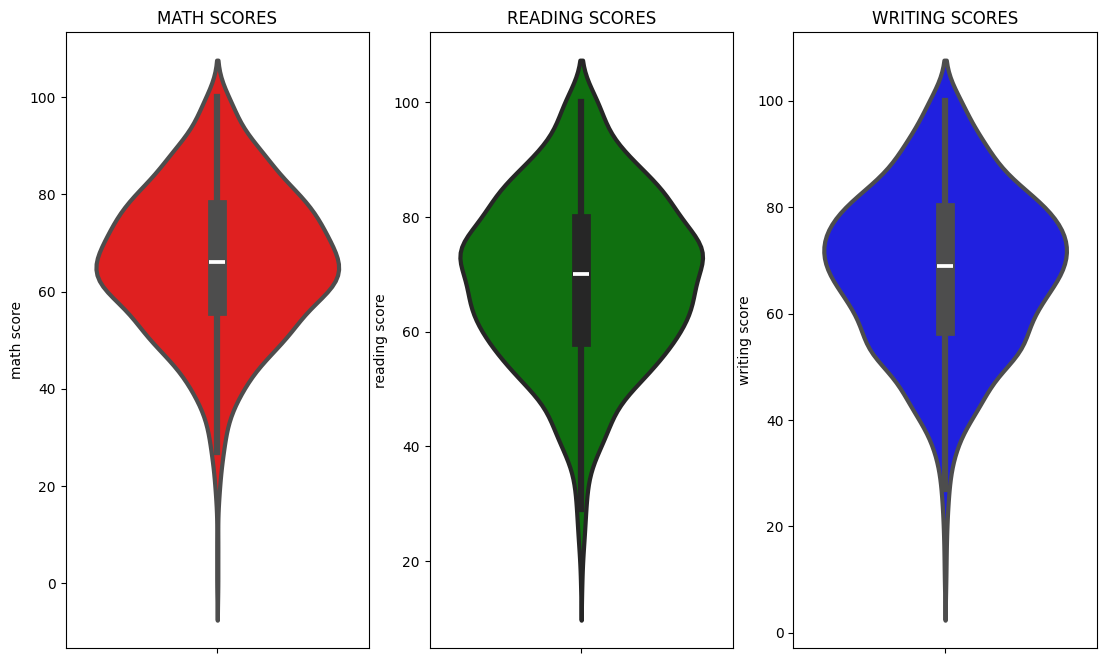

In [33]:

plt.figure(figsize=(18,8))
plt.subplot(1, 4, 1)
plt.title('MATH SCORES')
sns.violinplot(y='math score',data=df,color='red',linewidth=3)
plt.subplot(1, 4, 2)
plt.title('READING SCORES')
sns.violinplot(y='reading score',data=df,color='green',linewidth=3)
plt.subplot(1, 4, 3)
plt.title('WRITING SCORES')
sns.violinplot(y='writing score',data=df,color='blue',linewidth=3)
plt.show()
